# 02. Data Cleaning and Trajectory Preprocessing Pipeline
**Project:** Where Will This Vessel Be in 4–6 Hours?  
**Author:** Praneeth (ED23B032)  
**Assignment:** Blurgs.ai Take-Home  

---

### Cleaning Philosophy & Threshold Documentation
In this notebook, we transform noisy raw AIS broadcast points into clean, continuous vessel trajectories:
1. **Coordinate Verification:** Geographic bounds check ($-90 \le \text{lat} \le 90$, $-180 \le \text{lon} \le 180$).
2. **Deduplication:** Remove identical transmission packets with identical `(mmsi, base_date_time)`.
3. **Speed Filtering:** 
   - Exclude stationary and moored craft ($\text{SOG} < 0.5\text{ knots}$). Stationary vessels at anchor or berths do not represent active navigation.
   - Exclude extreme speed anomalies ($\text{SOG} > 40.0\text{ knots}$). Standard commercial cargo and tanker vessels operate at 10–25 knots; values above 40 knots are GPS jumps or transmission corruptions.
4. **Course Filtering:** Validate compass course bounds ($0^\circ \le \text{COG} \le 360^\circ$).
5. **Observation Gap Handling:** 
   - **Crucial Decision:** We do *not* blindly interpolate across long transmission dropouts (e.g. 2–4 hours). Interpolating across large gaps fabricates artificial paths where vessels might have stopped, maneuvered, or altered course.
   - **Solution:** Whenever the time gap between consecutive observations for a vessel exceeds **1.0 hour**, we split the track into distinct sub-trajectories.
6. **Usable Trajectory Criteria:** 
   - A trajectory must have a continuous duration of at least **10.0 hours** to support an input history of 4 hours plus a future forecasting horizon of 6 hours ($4 + 6 = 10\text{h}$).
   - A minimum of 20 observations per trajectory to ensure robust kinematic state estimation.


In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.append(project_root)

from src.data_loader import load_ais_data
from src.preprocessing import clean_ais_pipeline

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
print("Modules imported successfully.")


Modules imported successfully.


In [2]:
raw_path = os.path.join(project_root, "data", "raw", "ais_southeast_raw.parquet")
df_raw = load_ais_data(raw_path)
print(f"Loaded raw records: {len(df_raw):,}")
print(f"Raw vessels: {df_raw['mmsi'].nunique():,}")


Loaded raw records: 816,653
Raw vessels: 2,535


In [3]:
df_clean, report = clean_ais_pipeline(
    df_raw,
    min_lat=24.0, max_lat=32.0,
    min_lon=-85.0, max_lon=-78.0,
    min_sog=0.5, max_sog=40.0,
    max_gap_hours=1.0,
    min_points_per_trajectory=20,
    min_trajectory_hours=10.0
)

# Convert report to DataFrame for presentation
report_df = pd.DataFrame(list(report.items()), columns=["Pipeline_Stage", "Record_Count"])
report_df["Retention_Pct_From_Raw"] = (report_df["Record_Count"] / report["01_raw_records"]) * 100

print("=== DATA CLEANING & FILTERING FUNNEL ===")
print(report_df.to_string(index=False))


=== DATA CLEANING & FILTERING FUNNEL ===
              Pipeline_Stage  Record_Count  Retention_Pct_From_Raw
              01_raw_records        816653              100.000000
        02_valid_coordinates        816653              100.000000
             03_deduplicated        816638               99.998163
           04_speed_filtered        180118               22.055634
          05_course_filtered        175037               21.433461
     06_total_split_segments          2025                0.247963
      07_usable_trajectories           101                0.012368
08_usable_trajectory_records         60976                7.466574


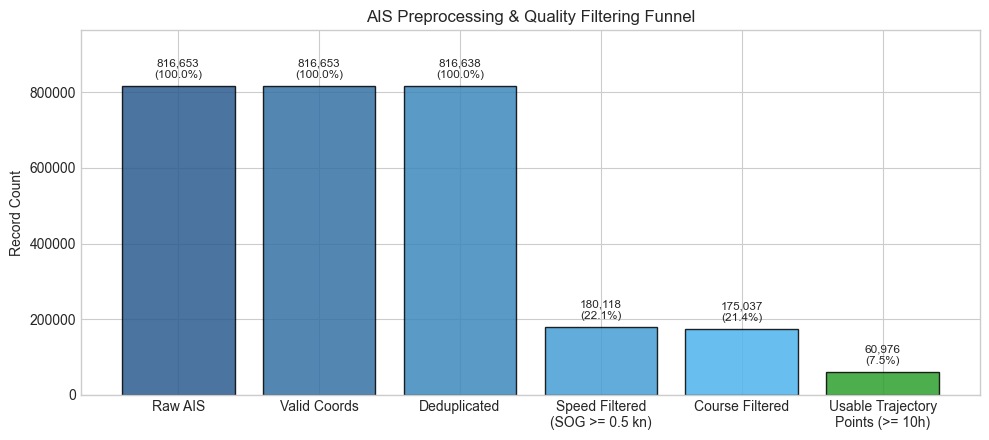

In [4]:
fig, ax = plt.subplots(figsize=(10, 4.5))

stage_labels = [
    "Raw AIS", "Valid Coords", "Deduplicated", 
    "Speed Filtered\n(SOG >= 0.5 kn)", "Course Filtered", 
    "Usable Trajectory\nPoints (>= 10h)"
]
stage_counts = [
    report["01_raw_records"], report["02_valid_coordinates"], 
    report["03_deduplicated"], report["04_speed_filtered"], 
    report["05_course_filtered"], report["08_usable_trajectory_records"]
]

bars = ax.bar(stage_labels, stage_counts, color=['#2b5c8f', '#3572a5', '#3d88bd', '#459ed5', '#4eb4ed', '#2ca02c'], edgecolor='black', alpha=0.85)
ax.set_title("AIS Preprocessing & Quality Filtering Funnel", fontsize=12)
ax.set_ylabel("Record Count")

for bar in bars:
    y = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2.0, y + 15000, f"{int(y):,}\n({(y/stage_counts[0])*100:.1f}%)", ha='center', va='bottom', fontsize=8.5)

ax.set_ylim(0, max(stage_counts) * 1.18)
plt.tight_layout()
funnel_fig = os.path.join(project_root, "results", "figures", "preprocessing_funnel.png")
plt.savefig(funnel_fig, dpi=150)
plt.show()


In [5]:
# Inspect properties of the cleaned trajectories
traj_summary = df_clean.groupby("trajectory_id").agg(
    mmsi=("mmsi", "first"),
    points=("base_date_time", "count"),
    start_time=("base_date_time", "min"),
    end_time=("base_date_time", "max"),
    mean_sog=("sog", "mean"),
    vessel_type=("vessel_type", "first")
)
traj_summary["duration_hours"] = (traj_summary["end_time"] - traj_summary["start_time"]).dt.total_seconds() / 3600.0

print(f"Total usable trajectories: {len(traj_summary)}")
print(f"Total points across trajectories: {len(df_clean):,}")
print(f"\nTrajectory Duration Statistics (hours):")
print(traj_summary["duration_hours"].describe())
print(f"\nObservations per Trajectory Statistics:")
print(traj_summary["points"].describe())


Total usable trajectories: 101
Total points across trajectories: 60,976

Trajectory Duration Statistics (hours):
count    101.000000
mean      15.729519
std        4.618858
min       10.066667
25%       11.918333
50%       14.574444
75%       19.783333
max       23.994722
Name: duration_hours, dtype: float64

Observations per Trajectory Statistics:
count     101.000000
mean      603.722772
std       248.519662
min        31.000000
25%       435.000000
50%       584.000000
75%       757.000000
max      1259.000000
Name: points, dtype: float64


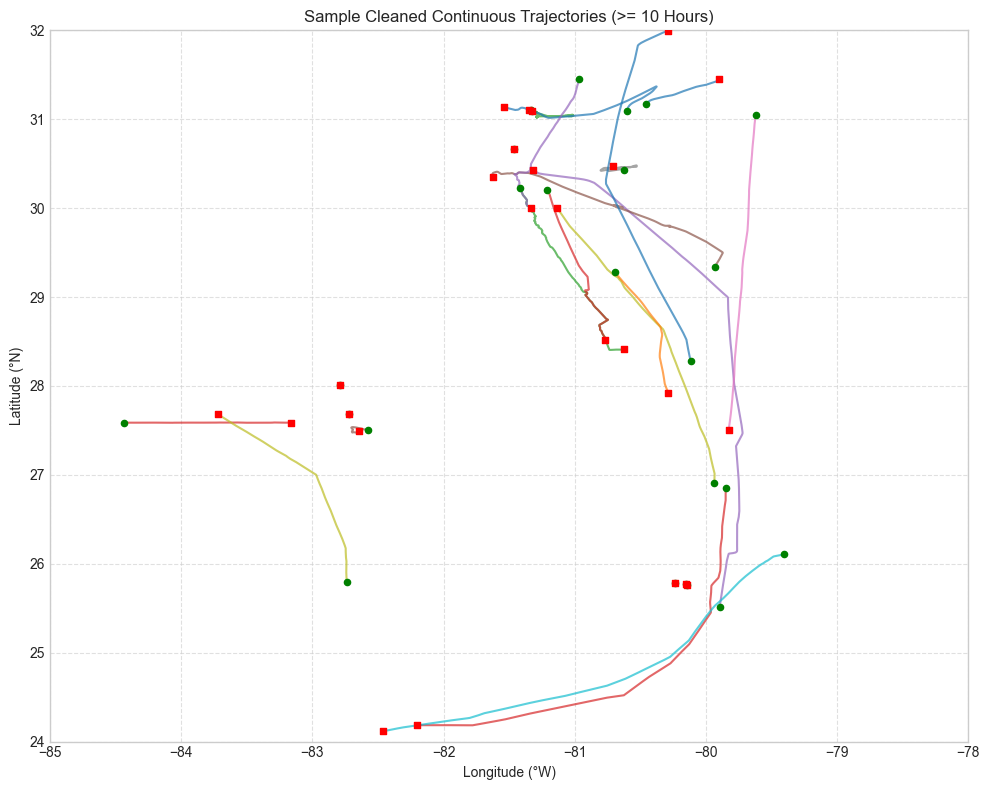

In [6]:
plt.figure(figsize=(10, 8))

# Plot tracks of top 20 longest trajectories
sample_trajs = traj_summary.sort_values(by="duration_hours", ascending=False).head(25).index

for tid in sample_trajs:
    sub = df_clean[df_clean["trajectory_id"] == tid]
    plt.plot(sub["longitude"], sub["latitude"], lw=1.5, alpha=0.7, label=tid if len(sample_trajs) <= 5 else None)
    # Mark start and end
    plt.scatter(sub["longitude"].iloc[0], sub["latitude"].iloc[0], marker='o', s=20, color='green', zorder=4)
    plt.scatter(sub["longitude"].iloc[-1], sub["latitude"].iloc[-1], marker='s', s=20, color='red', zorder=4)

plt.title("Sample Cleaned Continuous Trajectories (>= 10 Hours)", fontsize=12)
plt.xlabel("Longitude (°W)")
plt.ylabel("Latitude (°N)")
plt.xlim(-85.0, -78.0)
plt.ylim(24.0, 32.0)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig(os.path.join(project_root, "results", "figures", "cleaned_trajectories_sample.png"), dpi=150)
plt.show()


In [7]:
output_processed = os.path.join(project_root, "data", "processed", "ais_cleaned_trajectories.parquet")
df_clean.to_parquet(output_processed, index=False, compression="zstd")
print(f"Successfully saved cleaned trajectories to: {output_processed}")
print(f"File size: {os.path.getsize(output_processed)/(1024*1024):.2f} MB")


Successfully saved cleaned trajectories to: C:\Users\girik\.gemini\antigravity\scratch\Blurgs.ai_Assignment_ED23B032\data\processed\ais_cleaned_trajectories.parquet
File size: 1.40 MB
